In [35]:
import numpy as np
import math
import random
import csv
import pandas as pd
import scipy
import scipy.optimize as opt
from bayes_opt import BayesianOptimization
from bayes_opt.logger import JSONLogger
from bayes_opt.event import Events
from bayes_opt.util import load_logs
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def read_behavioral_data(n):
    result_stay_cue = []
    result_safe_risk = []
    action_stay_cue = []
    action_safe_risk = []
    if_can_ask = []
    fname = './behavioral_data/uncertainty_' + str(n+1) + '_2022.csv'
    with open(fname,'r') as f :
        for line in f.readlines():
            if line.split(',')[0]=='0' or line.split(',')[0]=='1':
                if int(line.split(',')[3])==0:
                    action_stay_cue.append(0)
                elif int(line.split(',')[3])==1 or int(line.split(',')[3])==2:
                    action_stay_cue.append(1)
                else :
                    print('ERROR')
                result_stay_cue.append(int(line.split(',')[3]))
                result_safe_risk.append(int(float(line.split(',')[6])))
                action_safe_risk.append(int(line.split(',')[4]))
                if line.split(',')[1]==' ':
                    if_can_ask.append(0)
                else :
                    if_can_ask.append(1)

    return if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk

In [3]:
def dir(a):
    a_0 = np.sum(a,axis=0)
    A = np.zeros([8,8])
    for i in range(np.shape(A)[0]):
        for j in range(np.shape(A)[1]):
            A[i,j] = a[i,j]/a_0[j]
    return A
def cum(a):
    a_0 = np.sum(a,axis=0)
    a_cum = np.array([np.ones([1,8])*a_0[0],
                      np.ones([1,8])*a_0[1],
                      np.ones([1,8])*a_0[2],
                      np.ones([1,8])*a_0[3],
                      np.ones([1,8])*a_0[4],
                      np.ones([1,8])*a_0[5],
                      np.ones([1,8])*a_0[6],
                      np.ones([1,8])*a_0[7]]).squeeze().T
    return a_cum
def H_entropy(A):
    H = np.matmul(A.T,np.log(A+np.e**(-16)))
    H = np.diag(H)
    return H
def G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex):
    a_nonzero = np.array([[1,1,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,0,0,1,1,0,0],
                      [0,0,0,0,0,0,1,0],
                      [0,0,0,0,0,0,0,1]])
    s = np.array(s)
    discount = 0.1
    o = np.dot(A,s.reshape(-1,1)).reshape(-1)
    w = 1./(cum(a))-1./(a+np.e**(-16))
    w = np.multiply(w,a_nonzero)
    H = -np.dot(H_entropy(A),s.reshape(-1,1))
    AL = np.dot(o,np.dot(w,s.reshape(-1,1)))
    AI = H + np.dot(o,np.log(o+np.e**(-16)).reshape(-1,1))
    preference = np.array([1,2,1.5,0.5,0,0,-0.167,-0.167])
    EX = np.dot(o,preference.reshape(-1,1))
    if action_stay_cue == 0:
        return float(discount*(p_al*AL + p_ai*AI) - p_ex*EX)
    elif action_stay_cue == 1:
        return float(p_al*AL + p_ai*AI - p_ex*EX)
    else :
        print('ERROR')
        
def P_stay_cue(A,a,action_stay_cue,if_can_ask,p_al,p_ai,p_ex):#stay,cue,0,stay-safe,1,stay-risk,2,cue-safe,3,cue-risk
    if if_can_ask == 0:
        return 1
    else:
        s1 = np.array([0,0,0,0,0.5,0.5,0,0])
        s2 = np.array([0.5,0.5,0,0,0,0,0,0])
        G_stay_safe = G_ExperctedFreeEnergy(A,a,s1,0,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,0,p_al,p_ai,p_ex)
        s1 = np.array([0,0,0,0,0.5,0.5,0,0])
        s2 = np.array([0,0,0.5,0.5,0,0,0,0])
        G_stay_risk = G_ExperctedFreeEnergy(A,a,s1,0,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,0,p_al,p_ai,p_ex)
        s1 = [0, 0, 0, 0, 0, 0, 0.5, 0.5]
        s2 = [1, 0, 0, 0, 0, 0, 0, 0]
        s3 = [0, 0, 0, 0, 0, 0, 0.5, 0.5]
        s4 = [0, 0, 1, 0, 0, 0, 0, 0]
        G_cue_HR_0 = G_ExperctedFreeEnergy(A, a, s1, 1, p_al, p_ai, p_ex) + G_ExperctedFreeEnergy(A, a, s2, 1, p_al, p_ai, p_ex)
        G_cue_HR_1 = G_ExperctedFreeEnergy(A, a, s3, 1, p_al, p_ai, p_ex) + G_ExperctedFreeEnergy(A, a, s4, 1, p_al, p_ai, p_ex)
        if G_cue_HR_0>G_cue_HR_1:
            G_cue_HR = G_cue_HR_1
        else:
            G_cue_HR = G_cue_HR_0
        s1 = [0, 0, 0, 0, 0, 0, 0.5, 0.5]
        s2 = [0, 1, 0, 0, 0, 0, 0, 0]
        s3 = [0, 0, 0, 0, 0, 0, 0.5, 0.5]
        s4 = [0, 0, 0, 1, 0, 0, 0, 0]
        G_cue_LR_0 = G_ExperctedFreeEnergy(A, a, s1, 1, p_al, p_ai, p_ex) + G_ExperctedFreeEnergy(A, a, s2, 1, p_al, p_ai, p_ex)
        G_cue_LR_1 = G_ExperctedFreeEnergy(A, a, s3, 1, p_al, p_ai, p_ex) + G_ExperctedFreeEnergy(A, a, s4, 1, p_al, p_ai, p_ex)
        if G_cue_LR_0>G_cue_LR_1:
            G_cue_LR = G_cue_LR_1
        else:
            G_cue_LR = G_cue_LR_0
        G_stay_cue = np.array([-min(G_stay_safe,G_stay_risk),-(G_cue_HR+G_cue_LR)/2])
        if G_stay_cue[0]>20:
            G_stay_cue[0]=20
        if G_stay_cue[1]>20:
            G_stay_cue[1]=20
        exp_G = [np.exp(G_stay_cue[0]),np.exp(G_stay_cue[1])]
        total = exp_G[0]+exp_G[1]
        P = [exp_G[0]/total,exp_G[1]/total]
        return P[action_stay_cue].squeeze()

def P_safe_risk(A,a,action_safe_risk,result_stay_cue,p_al,p_ai,p_ex):#con=0,no,con=1,HRC,con=2,LRC,pi=0,safe,pi=1,risky
    if result_stay_cue !=0:
        action_stay_cue = 1
    else :
        action_stay_cue = 0
    if result_stay_cue == 0:
        s=np.array([0.5,0.5,0,0,0,0,0,0])
        G_safe = -G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex)
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        G_risk = -G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex)
    elif result_stay_cue == 1:
        s=np.array([1,0,0,0,0,0,0,0])
        G_safe = -G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex)
        s=np.array([0,0,1,0,0,0,0,0])
        G_risk = -G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex)
    else :
        s=np.array([0,1,0,0,0,0,0,0])
        G_safe = -G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex)
        s=np.array([0,0,0,1,0,0,0,0])
        G_risk = -G_ExperctedFreeEnergy(A,a,s,action_stay_cue,p_al,p_ai,p_ex)
    if G_safe > 20:
        G_safe = 20
    if G_risk > 20:
        G_risk = 20
    exp_G = [np.exp(G_safe),np.exp(G_risk)]
    total = exp_G[0]+exp_G[1]
    P_safe_risk = [exp_G[0]/total,exp_G[1]/total]
    return P_safe_risk[action_safe_risk].squeeze()

def a_update(a,result_stay_cue,result_safe_risk,action_safe_risk,rate):
    if result_stay_cue==0 and result_safe_risk==6 and action_safe_risk==0:
        s=np.array([0.5,0.5,0,0,0,0,0,0])
#safeHRC,safeLRC,riskyHRC,riskLRC,stayHRC,stayLRC,cueHRC,cueLRC
        o=np.array([1,0,0,0,0,0,0,0])
#safe,riskyHR,riskyLR,stay,cueHR,cueLR
    elif result_stay_cue==0 and result_safe_risk==0:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,0,0,0,1,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==3:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,0,0,1,0,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==6 and action_safe_risk==1:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==9:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,0,1,0,0,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==12:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,1,0,0,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==6 and action_safe_risk==0:
        s=np.array([1,0,0,0,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==0:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,0,0,0,1,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==3:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,0,0,1,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==6 and action_safe_risk==1:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==9:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,0,1,0,0,0,0,0])      
    elif result_stay_cue==1 and result_safe_risk==12:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,1,0,0,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==6 and action_safe_risk==0:
        s=np.array([0,1,0,0,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==0:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,0,0,0,1,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==3:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,0,0,1,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==6 and action_safe_risk==1:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==9:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,0,1,0,0,0,0,0])    
    else :
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,1,0,0,0,0,0,0])
    if result_stay_cue!=0:
        a=a+rate*np.outer(o,s)#rate:learning rate
    else :
        a=a+rate*0.1*np.outer(o,s)
    return a

def P_active_inference(x):
    trial_num = 120
    subject_num = 25
    if_can_ask_sub = []
    action_stay_cue_sub = []
    result_stay_cue_sub = []
    action_safe_risk_sub = []
    result_safe_risk_sub = []
    for i in range(subject_num):
        if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(i)
        if_can_ask_sub.append(if_can_ask)
        action_stay_cue_sub.append(action_stay_cue)
        result_stay_cue_sub.append(result_stay_cue)
        action_safe_risk_sub.append(action_safe_risk)
        result_safe_risk_sub.append(result_safe_risk)
    rate = []
    prior = []
    p_al = []
    p_ai = []
    p_ex = []
    for i in range(subject_num):
        rate.append(x[i*5])
        prior.append(x[i*5+1])
        p_al.append(x[i*5+2])
        p_ai.append(x[i*5+3])
        p_ex.append(x[i*5+4])
    neg_log_p_policy = 0
    for i in range(subject_num):
        a = np.array([[100.0,100,prior[i],prior[i],0,0,0,0],
                  [0,0,prior[i],prior[i],0,0,0,0],
                  [0,0,prior[i],prior[i],0,0,0,0],
                  [0,0,prior[i],prior[i],0,0,0,0],
                  [0,0,prior[i],prior[i],0,0,0,0],
                  [0,0,0,0,100,100,0,0],
                  [0,0,0,0,0,0,100,0],
                  [0,0,0,0,0,0,0,100]])
        A = dir(a)
        for j in range(trial_num):
            neg_log_p_policy -= np.log(P_stay_cue(A,a,action_stay_cue_sub[i][j],if_can_ask_sub[i][j],p_al[i],p_ai[i],p_ex[i]))
            neg_log_p_policy -= np.log(P_safe_risk(A,a,action_safe_risk_sub[i][j],result_stay_cue_sub[i][j],p_al[i],p_ai[i],p_ex[i]))
            a = a_update(a,result_stay_cue_sub[i][j],result_safe_risk_sub[i][j],action_safe_risk_sub[i][j],rate[i])
            A = dir(a)
    return neg_log_p_policy

In [4]:
def P_action_softmax(value,gamma,state,action):
    Q = value[:,0]
    exp_Q = np.sum(np.exp(gamma*Q))
    return (np.exp(gamma*Q)/exp_Q)[action]

def P_action_con1(value,gamma):
    Q = value[:,1]
    exp_Q = np.sum(np.exp(Q*gamma))
    return np.exp(Q*gamma)/exp_Q

def P_action_con2(value,gamma):
    Q = value[:,2]
    exp_Q = np.sum(np.exp(Q*gamma))
    return np.exp(Q*gamma)/exp_Q
    
def P_action_con0(value,gamma):
    Q1 = (value[0,1]+value[0,2])/2
    Q2 = (value[1,1]+value[1,2])/2
    Q = np.array([Q1,Q2])
    exp_Q = np.sum(np.exp(Q*gamma))
    return np.exp(Q*gamma)/exp_Q

def learn(value,lr,states,actions,reward):
    if states==[0,1,0] or states==[0,0,1]:
        value[1,0] = value[1,0] + lr * (reward - 1 - value[1,0])
    else :
        value[0,0] = value[0,0] + lr * (reward - value[0,0])
    if actions==1:
        if states==[0,1,0]:
            value[1,1] = value[1,1] + lr*(reward-value[1,1])      
        elif states==[0,0,1]:
            value[1,2] = value[1,2] + lr*(reward-value[1,2])    
        else:
            value[1,1] = value[1,1] + 0.5*lr*(reward-value[1,1])      
            value[1,2] = value[1,2] + 0.5*lr*(reward-value[1,2])
    return value

def read_behavioral_data(n):
    result_stay_cue = []
    result_safe_risk = []
    action_stay_cue = []
    action_safe_risk = []
    if_can_ask = []
    fname = './behavioral_data/uncertainty_' + str(n+1) + '_2022.csv'
    with open(fname,'r') as f :
        for line in f.readlines():
            if line.split(',')[0]=='0' or line.split(',')[0]=='1':
                if int(line.split(',')[3])==0:
                    action_stay_cue.append(0)
                elif int(line.split(',')[3])==1 or int(line.split(',')[3])==2:
                    action_stay_cue.append(1)
                else :
                    print('ERROR')
                result_stay_cue.append(int(line.split(',')[3]))
                result_safe_risk.append(int(float(line.split(',')[6])))
                action_safe_risk.append(int(line.split(',')[4]))
                if line.split(',')[1]==' ':
                    if_can_ask.append(0)
                else :
                    if_can_ask.append(1)

    return if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk

def P_model_free_rl(gamma,lr):
    subject = 0
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

In [5]:
def dir(a):
    a_0 = np.sum(a,axis=0)
    A = np.zeros([8,8])
    for i in range(np.shape(A)[0]):
        for j in range(np.shape(A)[1]):
            A[i,j] = a[i,j]/a_0[j]
    return A

def a_update(a,result_stay_cue,result_safe_risk,action_safe_risk,rate):
    if result_stay_cue==0 and result_safe_risk==6 and action_safe_risk==0:
        s=np.array([0.5,0.5,0,0,0,0,0,0])
        #safeHRC,safeLRC,riskyHRC,riskLRC,stayHRC,stayLRC,cueHRC,cueLRC
        o=np.array([1,0,0,0,0,0,0,0])
        #safe,riskyHR,riskyLR,stay,cueHR,cueLR
    elif result_stay_cue==0 and result_safe_risk==0:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,0,0,0,1,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==3:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,0,0,1,0,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==6 and action_safe_risk==1:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==9:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,0,1,0,0,0,0,0])
    elif result_stay_cue==0 and result_safe_risk==12:
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        o=np.array([0,1,0,0,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==6 and action_safe_risk==0:
        s=np.array([1,0,0,0,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==0:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,0,0,0,1,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==3:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,0,0,1,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==6 and action_safe_risk==1:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==1 and result_safe_risk==9:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,0,1,0,0,0,0,0])      
    elif result_stay_cue==1 and result_safe_risk==12:
        s=np.array([0,0,1,0,0,0,0,0])
        o=np.array([0,1,0,0,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==6 and action_safe_risk==0:
        s=np.array([0,1,0,0,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==0:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,0,0,0,1,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==3:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,0,0,1,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==6 and action_safe_risk==1:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([1,0,0,0,0,0,0,0])
    elif result_stay_cue==2 and result_safe_risk==9:
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,0,1,0,0,0,0,0])    
    else :
        s=np.array([0,0,0,1,0,0,0,0])
        o=np.array([0,1,0,0,0,0,0,0])
    if result_stay_cue!=0:
        a=a+rate*np.outer(o,s)#rate:learning rate
    else :
        a=a+rate*0.1*np.outer(o,s)
    return a

def P_action_stay_cue(A,gamma,action):
    preference = np.array([6,12,9,3,0,0,-1,-1])
    Q_risk_H = np.dot(A[:,2],preference)
    Q_risk_L = np.dot(A[:,3],preference)
    Q_stay = max(6,(Q_risk_H+Q_risk_L)/2)
    Q_cue = (max(5,Q_risk_H-1)+max(5,Q_risk_L-1))/2
    Q_stay_cue = np.array([Q_stay,Q_cue])
    exp_Q = np.sum(np.exp(gamma*Q_stay_cue))
    return (np.exp(gamma*Q_stay_cue)/exp_Q)[action]

def P_action_safe_risk(A,gamma,result_stay_cue,action):
    preference = np.array([6,12,9,3,0,0,-1,-1])
    Q_risk_H = np.dot(A[:,2],preference)
    Q_risk_L = np.dot(A[:,3],preference)
    Q_safe = 6
    if result_stay_cue == 1:
        Q_safe_risk = np.array([Q_safe,Q_risk_H])
    elif result_stay_cue == 2:
        Q_safe_risk = np.array([Q_safe,Q_risk_L])
    else:
        Q_safe_risk = np.array([Q_safe,(Q_risk_H+Q_risk_L)/2])
    exp_Q = np.sum(np.exp(gamma*Q_safe_risk))    
    return (np.exp(gamma*Q_safe_risk)/exp_Q)[action]

def P_model_based_RL(prior,rate,gamma):
    subject = 0
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

In [6]:
def P_active_inference_subject_1(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 0

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_2(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 1

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_3(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 2

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_4(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 3

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_5(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 4

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_6(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 5

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_7(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 6

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_8(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 7

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_9(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 8

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_10(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 9

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_11(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 10

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_12(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 11

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_13(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 12

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_14(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 13

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_15(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 14

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_16(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 15

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_17(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 16

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_18(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 17

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_19(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 18

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_20(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 19

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_21(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 20

    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_22(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 21
    
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_23(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 22
    
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_24(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 23
    
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy
def P_active_inference_subject_25(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 24
    
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy

In [9]:
def P_model_free_rl_1(gamma,lr):
    subject = 0
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_2(gamma,lr):
    subject = 1
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_3(gamma,lr):
    subject = 2
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_4(gamma,lr):
    subject = 3
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_5(gamma,lr):
    subject = 4
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_6(gamma,lr):
    subject = 5
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_7(gamma,lr):
    subject = 6
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_8(gamma,lr):
    subject = 7
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_9(gamma,lr):
    subject = 8
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_10(gamma,lr):
    subject = 9
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_11(gamma,lr):
    subject = 10
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_12(gamma,lr):
    subject = 11
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p


def P_model_free_rl_13(gamma,lr):
    subject = 12
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_14(gamma,lr):
    subject = 13
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_15(gamma,lr):
    subject = 14
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_16(gamma,lr):
    subject = 15
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_17(gamma,lr):
    subject = 16
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_18(gamma,lr):
    subject = 17
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_19(gamma,lr):
    subject = 18
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_20(gamma,lr):
    subject = 19
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_21(gamma,lr):
    subject = 20
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_22(gamma,lr):
    subject = 21
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_23(gamma,lr):
    subject = 22
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_24(gamma,lr):
    subject = 23
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

def P_model_free_rl_25(gamma,lr):
    subject = 24
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    value = np.array([[6,6,6],[6,6,6]])
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_softmax(value,gamma,[1,0,0],action_stay_cue[i]))
        if result_stay_cue[i]==0:
            state = [0,0.5,0.5]
            log_p += np.log(P_action_con0(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==1:
            state = [0,1,0]
            log_p += np.log(P_action_con1(value,gamma)[action_safe_risk[i]])
        elif result_stay_cue[i]==2:
            state=[0,0,1]
            log_p += np.log(P_action_con2(value,gamma)[action_safe_risk[i]])
        else:
            print('ERROR')
        value = learn(value,lr,state,action_safe_risk[i],result_safe_risk[i])
    return log_p

In [10]:
def P_model_based_rl_1(prior,rate,gamma):
    subject = 0
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_2(prior,rate,gamma):
    subject = 1
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_3(prior,rate,gamma):
    subject = 2
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_4(prior,rate,gamma):
    subject = 3
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_5(prior,rate,gamma):
    subject = 4
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_6(prior,rate,gamma):
    subject = 5
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_7(prior,rate,gamma):
    subject = 6
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_8(prior,rate,gamma):
    subject = 7
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_9(prior,rate,gamma):
    subject = 8
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_10(prior,rate,gamma):
    subject = 9
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_11(prior,rate,gamma):
    subject = 10
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_12(prior,rate,gamma):
    subject = 11
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_13(prior,rate,gamma):
    subject = 12
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_14(prior,rate,gamma):
    subject = 13
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_15(prior,rate,gamma):
    subject = 14
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_16(prior,rate,gamma):
    subject = 15
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_17(prior,rate,gamma):
    subject = 16
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_18(prior,rate,gamma):
    subject = 17
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_19(prior,rate,gamma):
    subject = 18
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_20(prior,rate,gamma):
    subject = 19
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_21(prior,rate,gamma):
    subject = 20
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_22(prior,rate,gamma):
    subject = 21
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_23(prior,rate,gamma):
    subject = 22
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_24(prior,rate,gamma):
    subject = 23
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

def P_model_based_rl_25(prior,rate,gamma):
    subject = 24
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p = 0
    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for i in range(120):
        if if_can_ask[i] == 1:
            log_p += np.log(P_action_stay_cue(A,gamma,action_stay_cue[i]))
        log_p += np.log(P_action_safe_risk(A,gamma,result_stay_cue[i],action_safe_risk[i]))
        a = a_update(a,result_stay_cue[i],result_safe_risk[i],action_safe_risk[i],rate)
        A = dir(a)
    return log_p

In [19]:
P_AL,P_AI,P_EX,PRIOR,RATE,LL = [],[],[],[],[],[]
pbounds = {'rate':(0.001,10),'prior':(0.001,10),'p_al':(0.001,10),'p_ai':(0.001,10),'p_ex':(0.001,10)}

optimizer_1 = BayesianOptimization(
    f=P_active_inference_subject_1,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_1, logs=["./behavioral_data/logs_1.log.json"])
P_AL.append(optimizer_1.max['params']['p_al'])
P_AI.append(optimizer_1.max['params']['p_ai'])
P_EX.append(optimizer_1.max['params']['p_ex'])
RATE.append(optimizer_1.max['params']['rate'])
PRIOR.append(optimizer_1.max['params']['prior'])
LL.append(optimizer_1.max['target'])

optimizer_2 = BayesianOptimization(
    f=P_active_inference_subject_2,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_2, logs=["./behavioral_data/logs_2.log.json"])
P_AL.append(optimizer_2.max['params']['p_al'])
P_AI.append(optimizer_2.max['params']['p_ai'])
P_EX.append(optimizer_2.max['params']['p_ex'])
RATE.append(optimizer_2.max['params']['rate'])
PRIOR.append(optimizer_2.max['params']['prior'])
LL.append(optimizer_2.max['target'])

optimizer_3 = BayesianOptimization(
    f=P_active_inference_subject_3,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_3, logs=["./behavioral_data/logs_3.log.json"])
P_AL.append(optimizer_3.max['params']['p_al'])
P_AI.append(optimizer_3.max['params']['p_ai'])
P_EX.append(optimizer_3.max['params']['p_ex'])
RATE.append(optimizer_3.max['params']['rate'])
PRIOR.append(optimizer_3.max['params']['prior'])
LL.append(optimizer_3.max['target'])

optimizer_4 = BayesianOptimization(
    f=P_active_inference_subject_4,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_4, logs=["./behavioral_data/logs_4.log.json"])
P_AL.append(optimizer_4.max['params']['p_al'])
P_AI.append(optimizer_4.max['params']['p_ai'])
P_EX.append(optimizer_4.max['params']['p_ex'])
RATE.append(optimizer_4.max['params']['rate'])
PRIOR.append(optimizer_4.max['params']['prior'])
LL.append(optimizer_4.max['target'])

optimizer_5 = BayesianOptimization(
    f=P_active_inference_subject_5,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_5, logs=["./behavioral_data/logs_5.log.json"])
P_AL.append(optimizer_5.max['params']['p_al'])
P_AI.append(optimizer_5.max['params']['p_ai'])
P_EX.append(optimizer_5.max['params']['p_ex'])
RATE.append(optimizer_5.max['params']['rate'])
PRIOR.append(optimizer_5.max['params']['prior'])
LL.append(optimizer_5.max['target'])

optimizer_6 = BayesianOptimization(
    f=P_active_inference_subject_6,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_6, logs=["./behavioral_data/logs_6.log.json"])
P_AL.append(optimizer_6.max['params']['p_al'])
P_AI.append(optimizer_6.max['params']['p_ai'])
P_EX.append(optimizer_6.max['params']['p_ex'])
RATE.append(optimizer_6.max['params']['rate'])
PRIOR.append(optimizer_6.max['params']['prior'])
LL.append(optimizer_6.max['target'])

optimizer_7 = BayesianOptimization(
    f=P_active_inference_subject_7,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_7, logs=["./behavioral_data/logs_7.log.json"])
P_AL.append(optimizer_7.max['params']['p_al'])
P_AI.append(optimizer_7.max['params']['p_ai'])
P_EX.append(optimizer_7.max['params']['p_ex'])
RATE.append(optimizer_7.max['params']['rate'])
PRIOR.append(optimizer_7.max['params']['prior'])
LL.append(optimizer_7.max['target'])

optimizer_8 = BayesianOptimization(
    f=P_active_inference_subject_8,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_8, logs=["./behavioral_data/logs_8.log.json"])
P_AL.append(optimizer_8.max['params']['p_al'])
P_AI.append(optimizer_8.max['params']['p_ai'])
P_EX.append(optimizer_8.max['params']['p_ex'])
RATE.append(optimizer_8.max['params']['rate'])
PRIOR.append(optimizer_8.max['params']['prior'])
LL.append(optimizer_8.max['target'])

optimizer_9 = BayesianOptimization(
    f=P_active_inference_subject_9,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_9, logs=["./behavioral_data/logs_9.log.json"])
P_AL.append(optimizer_9.max['params']['p_al'])
P_AI.append(optimizer_9.max['params']['p_ai'])
P_EX.append(optimizer_9.max['params']['p_ex'])
RATE.append(optimizer_9.max['params']['rate'])
PRIOR.append(optimizer_9.max['params']['prior'])
LL.append(optimizer_9.max['target'])

optimizer_10 = BayesianOptimization(
    f=P_active_inference_subject_10,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_10, logs=["./behavioral_data/logs_10.log.json"])
P_AL.append(optimizer_10.max['params']['p_al'])
P_AI.append(optimizer_10.max['params']['p_ai'])
P_EX.append(optimizer_10.max['params']['p_ex'])
RATE.append(optimizer_10.max['params']['rate'])
PRIOR.append(optimizer_10.max['params']['prior'])
LL.append(optimizer_10.max['target'])

optimizer_11 = BayesianOptimization(
    f=P_active_inference_subject_11,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_11, logs=["./behavioral_data/logs_11.log.json"])
P_AL.append(optimizer_11.max['params']['p_al'])
P_AI.append(optimizer_11.max['params']['p_ai'])
P_EX.append(optimizer_11.max['params']['p_ex'])
RATE.append(optimizer_11.max['params']['rate'])
PRIOR.append(optimizer_11.max['params']['prior'])
LL.append(optimizer_11.max['target'])

optimizer_12 = BayesianOptimization(
    f=P_active_inference_subject_12,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_12, logs=["./behavioral_data/logs_12.log.json"])
P_AL.append(optimizer_12.max['params']['p_al'])
P_AI.append(optimizer_12.max['params']['p_ai'])
P_EX.append(optimizer_12.max['params']['p_ex'])
RATE.append(optimizer_12.max['params']['rate'])
PRIOR.append(optimizer_12.max['params']['prior'])
LL.append(optimizer_12.max['target'])

optimizer_13 = BayesianOptimization(
    f=P_active_inference_subject_13,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_13, logs=["./behavioral_data/logs_13.log.json"])
P_AL.append(optimizer_13.max['params']['p_al'])
P_AI.append(optimizer_13.max['params']['p_ai'])
P_EX.append(optimizer_13.max['params']['p_ex'])
RATE.append(optimizer_13.max['params']['rate'])
PRIOR.append(optimizer_13.max['params']['prior'])
LL.append(optimizer_13.max['target'])

optimizer_14 = BayesianOptimization(
    f=P_active_inference_subject_14,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_14, logs=["./behavioral_data/logs_14.log.json"])
P_AL.append(optimizer_14.max['params']['p_al'])
P_AI.append(optimizer_14.max['params']['p_ai'])
P_EX.append(optimizer_14.max['params']['p_ex'])
RATE.append(optimizer_14.max['params']['rate'])
PRIOR.append(optimizer_14.max['params']['prior'])
LL.append(optimizer_14.max['target'])

optimizer_15 = BayesianOptimization(
    f=P_active_inference_subject_15,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_15, logs=["./behavioral_data/logs_15.log.json"])
P_AL.append(optimizer_15.max['params']['p_al'])
P_AI.append(optimizer_15.max['params']['p_ai'])
P_EX.append(optimizer_15.max['params']['p_ex'])
RATE.append(optimizer_15.max['params']['rate'])
PRIOR.append(optimizer_15.max['params']['prior'])
LL.append(optimizer_15.max['target'])

optimizer_16 = BayesianOptimization(
    f=P_active_inference_subject_16,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_16, logs=["./behavioral_data/logs_16.log.json"])
P_AL.append(optimizer_16.max['params']['p_al'])
P_AI.append(optimizer_16.max['params']['p_ai'])
P_EX.append(optimizer_16.max['params']['p_ex'])
RATE.append(optimizer_16.max['params']['rate'])
PRIOR.append(optimizer_16.max['params']['prior'])
LL.append(optimizer_16.max['target'])

optimizer_17 = BayesianOptimization(
    f=P_active_inference_subject_17,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_17, logs=["./behavioral_data/logs_17.log.json"])
P_AL.append(optimizer_17.max['params']['p_al'])
P_AI.append(optimizer_17.max['params']['p_ai'])
P_EX.append(optimizer_17.max['params']['p_ex'])
RATE.append(optimizer_17.max['params']['rate'])
PRIOR.append(optimizer_17.max['params']['prior'])
LL.append(optimizer_17.max['target'])

optimizer_18 = BayesianOptimization(
    f=P_active_inference_subject_18,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_18, logs=["./behavioral_data/logs_18.log.json"])
P_AL.append(optimizer_18.max['params']['p_al'])
P_AI.append(optimizer_18.max['params']['p_ai'])
P_EX.append(optimizer_18.max['params']['p_ex'])
RATE.append(optimizer_18.max['params']['rate'])
PRIOR.append(optimizer_18.max['params']['prior'])
LL.append(optimizer_18.max['target'])

optimizer_19 = BayesianOptimization(
    f=P_active_inference_subject_19,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_19, logs=["./behavioral_data/logs_19.log.json"])
P_AL.append(optimizer_19.max['params']['p_al'])
P_AI.append(optimizer_19.max['params']['p_ai'])
P_EX.append(optimizer_19.max['params']['p_ex'])
RATE.append(optimizer_19.max['params']['rate'])
PRIOR.append(optimizer_19.max['params']['prior'])
LL.append(optimizer_19.max['target'])

optimizer_20 = BayesianOptimization(
    f=P_active_inference_subject_20,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_20, logs=["./behavioral_data/logs_20.log.json"])
P_AL.append(optimizer_20.max['params']['p_al'])
P_AI.append(optimizer_20.max['params']['p_ai'])
P_EX.append(optimizer_20.max['params']['p_ex'])
RATE.append(optimizer_20.max['params']['rate'])
PRIOR.append(optimizer_20.max['params']['prior'])
LL.append(optimizer_20.max['target'])

optimizer_21 = BayesianOptimization(
    f=P_active_inference_subject_21,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_21, logs=["./behavioral_data/logs_21.log.json"])
P_AL.append(optimizer_21.max['params']['p_al'])
P_AI.append(optimizer_21.max['params']['p_ai'])
P_EX.append(optimizer_21.max['params']['p_ex'])
RATE.append(optimizer_21.max['params']['rate'])
PRIOR.append(optimizer_21.max['params']['prior'])
LL.append(optimizer_21.max['target'])

optimizer_22 = BayesianOptimization(
    f=P_active_inference_subject_22,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_22, logs=["./behavioral_data/logs_22.log.json"])
P_AL.append(optimizer_22.max['params']['p_al'])
P_AI.append(optimizer_22.max['params']['p_ai'])
P_EX.append(optimizer_22.max['params']['p_ex'])
RATE.append(optimizer_22.max['params']['rate'])
PRIOR.append(optimizer_22.max['params']['prior'])
LL.append(optimizer_22.max['target'])

optimizer_23 = BayesianOptimization(
    f=P_active_inference_subject_23,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_23, logs=["./behavioral_data/logs_23.log.json"])
P_AL.append(optimizer_23.max['params']['p_al'])
P_AI.append(optimizer_23.max['params']['p_ai'])
P_EX.append(optimizer_23.max['params']['p_ex'])
RATE.append(optimizer_23.max['params']['rate'])
PRIOR.append(optimizer_23.max['params']['prior'])
LL.append(optimizer_23.max['target'])

optimizer_24 = BayesianOptimization(
    f=P_active_inference_subject_24,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_24, logs=["./behavioral_data/logs_24.log.json"])
P_AL.append(optimizer_24.max['params']['p_al'])
P_AI.append(optimizer_24.max['params']['p_ai'])
P_EX.append(optimizer_24.max['params']['p_ex'])
RATE.append(optimizer_24.max['params']['rate'])
PRIOR.append(optimizer_24.max['params']['prior'])
LL.append(optimizer_24.max['target'])

optimizer_25 = BayesianOptimization(
    f=P_active_inference_subject_25,
    pbounds=pbounds,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_25, logs=["./behavioral_data/logs_25.log.json"])
P_AL.append(optimizer_25.max['params']['p_al'])
P_AI.append(optimizer_25.max['params']['p_ai'])
P_EX.append(optimizer_25.max['params']['p_ex'])
RATE.append(optimizer_25.max['params']['rate'])
PRIOR.append(optimizer_25.max['params']['prior'])
LL.append(optimizer_25.max['target'])


Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 1 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 2 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 3 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 4 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 5 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 6 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 7 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 8 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 9 duplicates registered. Continuing ...
Data point [1.e-03 1.e-03 1.e+01 1.e+01 1.e-03] is not unique. 10 duplica

In [11]:
GAMMA_rl,LR_rl,LL_rl = [],[],[]
pbounds_rl = {'gamma':(0.001,10),'lr':(0.0,1)}

optimizer_rl_1 = BayesianOptimization(
    f=P_model_free_rl_1,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_1, logs=["./behavioral_data/logs_rl_1.log.json"])
GAMMA_rl.append(optimizer_rl_1.max['params']['gamma'])
LR_rl.append(optimizer_rl_1.max['params']['lr'])
LL_rl.append(optimizer_rl_1.max['target'])

optimizer_rl_2 = BayesianOptimization(
    f=P_model_free_rl_2,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_2, logs=["./behavioral_data/logs_rl_2.log.json"])
GAMMA_rl.append(optimizer_rl_2.max['params']['gamma'])
LR_rl.append(optimizer_rl_2.max['params']['lr'])
LL_rl.append(optimizer_rl_2.max['target'])

optimizer_rl_3 = BayesianOptimization(
    f=P_model_free_rl_3,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_3, logs=["./behavioral_data/logs_rl_3.log.json"])
GAMMA_rl.append(optimizer_rl_3.max['params']['gamma'])
LR_rl.append(optimizer_rl_3.max['params']['lr'])
LL_rl.append(optimizer_rl_3.max['target'])

optimizer_rl_4 = BayesianOptimization(
    f=P_model_free_rl_4,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_4, logs=["./behavioral_data/logs_rl_4.log.json"])
GAMMA_rl.append(optimizer_rl_4.max['params']['gamma'])
LR_rl.append(optimizer_rl_4.max['params']['lr'])
LL_rl.append(optimizer_rl_4.max['target'])

optimizer_rl_5 = BayesianOptimization(
    f=P_model_free_rl_5,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_5, logs=["./behavioral_data/logs_rl_5.log.json"])
GAMMA_rl.append(optimizer_rl_5.max['params']['gamma'])
LR_rl.append(optimizer_rl_5.max['params']['lr'])
LL_rl.append(optimizer_rl_5.max['target'])

optimizer_rl_6 = BayesianOptimization(
    f=P_model_free_rl_6,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_6, logs=["./behavioral_data/logs_rl_6.log.json"])
GAMMA_rl.append(optimizer_rl_6.max['params']['gamma'])
LR_rl.append(optimizer_rl_6.max['params']['lr'])
LL_rl.append(optimizer_rl_6.max['target'])

optimizer_rl_7 = BayesianOptimization(
    f=P_model_free_rl_7,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_7, logs=["./behavioral_data/logs_rl_7.log.json"])
GAMMA_rl.append(optimizer_rl_7.max['params']['gamma'])
LR_rl.append(optimizer_rl_7.max['params']['lr'])
LL_rl.append(optimizer_rl_7.max['target'])

optimizer_rl_8 = BayesianOptimization(
    f=P_model_free_rl_8,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_8, logs=["./behavioral_data/logs_rl_8.log.json"])
GAMMA_rl.append(optimizer_rl_8.max['params']['gamma'])
LR_rl.append(optimizer_rl_8.max['params']['lr'])
LL_rl.append(optimizer_rl_8.max['target'])

optimizer_rl_9 = BayesianOptimization(
    f=P_model_free_rl_9,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_9, logs=["./behavioral_data/logs_rl_9.log.json"])
GAMMA_rl.append(optimizer_rl_9.max['params']['gamma'])
LR_rl.append(optimizer_rl_9.max['params']['lr'])
LL_rl.append(optimizer_rl_9.max['target'])

optimizer_rl_10 = BayesianOptimization(
    f=P_model_free_rl_10,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_10, logs=["./behavioral_data/logs_rl_10.log.json"])
GAMMA_rl.append(optimizer_rl_10.max['params']['gamma'])
LR_rl.append(optimizer_rl_10.max['params']['lr'])
LL_rl.append(optimizer_rl_10.max['target'])

optimizer_rl_11 = BayesianOptimization(
    f=P_model_free_rl_11,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_11, logs=["./behavioral_data/logs_rl_11.log.json"])
GAMMA_rl.append(optimizer_rl_11.max['params']['gamma'])
LR_rl.append(optimizer_rl_11.max['params']['lr'])
LL_rl.append(optimizer_rl_11.max['target'])

optimizer_rl_12 = BayesianOptimization(
    f=P_model_free_rl_12,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_12, logs=["./behavioral_data/logs_rl_12.log.json"])
GAMMA_rl.append(optimizer_rl_12.max['params']['gamma'])
LR_rl.append(optimizer_rl_12.max['params']['lr'])
LL_rl.append(optimizer_rl_12.max['target'])

optimizer_rl_13 = BayesianOptimization(
    f=P_model_free_rl_13,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_13, logs=["./behavioral_data/logs_rl_13.log.json"])
GAMMA_rl.append(optimizer_rl_13.max['params']['gamma'])
LR_rl.append(optimizer_rl_13.max['params']['lr'])
LL_rl.append(optimizer_rl_13.max['target'])

optimizer_rl_14 = BayesianOptimization(
    f=P_model_free_rl_14,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_14, logs=["./behavioral_data/logs_rl_14.log.json"])
GAMMA_rl.append(optimizer_rl_14.max['params']['gamma'])
LR_rl.append(optimizer_rl_14.max['params']['lr'])
LL_rl.append(optimizer_rl_14.max['target'])

optimizer_rl_15 = BayesianOptimization(
    f=P_model_free_rl_15,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_15, logs=["./behavioral_data/logs_rl_15.log.json"])
GAMMA_rl.append(optimizer_rl_15.max['params']['gamma'])
LR_rl.append(optimizer_rl_15.max['params']['lr'])
LL_rl.append(optimizer_rl_15.max['target'])

optimizer_rl_16 = BayesianOptimization(
    f=P_model_free_rl_16,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_16, logs=["./behavioral_data/logs_rl_16.log.json"])
GAMMA_rl.append(optimizer_rl_16.max['params']['gamma'])
LR_rl.append(optimizer_rl_16.max['params']['lr'])
LL_rl.append(optimizer_rl_16.max['target'])

optimizer_rl_17 = BayesianOptimization(
    f=P_model_free_rl_17,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_17, logs=["./behavioral_data/logs_rl_17.log.json"])
GAMMA_rl.append(optimizer_rl_17.max['params']['gamma'])
LR_rl.append(optimizer_rl_17.max['params']['lr'])
LL_rl.append(optimizer_rl_17.max['target'])

optimizer_rl_18 = BayesianOptimization(
    f=P_model_free_rl_18,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_18, logs=["./behavioral_data/logs_rl_18.log.json"])
GAMMA_rl.append(optimizer_rl_18.max['params']['gamma'])
LR_rl.append(optimizer_rl_18.max['params']['lr'])
LL_rl.append(optimizer_rl_18.max['target'])

optimizer_rl_19 = BayesianOptimization(
    f=P_model_free_rl_19,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_19, logs=["./behavioral_data/logs_rl_19.log.json"])
GAMMA_rl.append(optimizer_rl_19.max['params']['gamma'])
LR_rl.append(optimizer_rl_19.max['params']['lr'])
LL_rl.append(optimizer_rl_19.max['target'])

optimizer_rl_20 = BayesianOptimization(
    f=P_model_free_rl_20,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_20, logs=["./behavioral_data/logs_rl_20.log.json"])
GAMMA_rl.append(optimizer_rl_20.max['params']['gamma'])
LR_rl.append(optimizer_rl_20.max['params']['lr'])
LL_rl.append(optimizer_rl_20.max['target'])

optimizer_rl_21 = BayesianOptimization(
    f=P_model_free_rl_21,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_21, logs=["./behavioral_data/logs_rl_21.log.json"])
GAMMA_rl.append(optimizer_rl_21.max['params']['gamma'])
LR_rl.append(optimizer_rl_21.max['params']['lr'])
LL_rl.append(optimizer_rl_21.max['target'])

optimizer_rl_22 = BayesianOptimization(
    f=P_model_free_rl_22,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_22, logs=["./behavioral_data/logs_rl_22.log.json"])
GAMMA_rl.append(optimizer_rl_22.max['params']['gamma'])
LR_rl.append(optimizer_rl_22.max['params']['lr'])
LL_rl.append(optimizer_rl_22.max['target'])

optimizer_rl_23 = BayesianOptimization(
    f=P_model_free_rl_23,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_23, logs=["./behavioral_data/logs_rl_23.log.json"])
GAMMA_rl.append(optimizer_rl_23.max['params']['gamma'])
LR_rl.append(optimizer_rl_23.max['params']['lr'])
LL_rl.append(optimizer_rl_23.max['target'])

optimizer_rl_24 = BayesianOptimization(
    f=P_model_free_rl_24,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_24, logs=["./behavioral_data/logs_rl_24.log.json"])
GAMMA_rl.append(optimizer_rl_24.max['params']['gamma'])
LR_rl.append(optimizer_rl_24.max['params']['lr'])
LL_rl.append(optimizer_rl_24.max['target'])

optimizer_rl_25 = BayesianOptimization(
    f=P_model_free_rl_25,
    pbounds=pbounds_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_rl_25, logs=["./behavioral_data/logs_rl_25.log.json"])
GAMMA_rl.append(optimizer_rl_25.max['params']['gamma'])
LR_rl.append(optimizer_rl_25.max['params']['lr'])
LL_rl.append(optimizer_rl_25.max['target'])

In [12]:
PRIOR_m_rl,RATE_m_rl,GAMMA_m_rl,LL_m_rl = [],[],[],[]
pbounds_m_rl = {'prior':(0.1,10),'rate':(0.001,10),'gamma':(0.001,10)}

optimizer_m_rl_1 = BayesianOptimization(
    f=P_model_based_rl_1,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_1, logs=["./behavioral_data/logs_m_rl_1.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_1.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_1.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_1.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_1.max['target'])

optimizer_m_rl_2 = BayesianOptimization(
    f=P_model_based_rl_2,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_2, logs=["./behavioral_data/logs_m_rl_2.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_2.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_2.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_2.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_2.max['target'])

optimizer_m_rl_3 = BayesianOptimization(
    f=P_model_based_rl_3,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_3, logs=["./behavioral_data/logs_m_rl_3.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_3.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_3.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_3.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_3.max['target'])

optimizer_m_rl_4 = BayesianOptimization(
    f=P_model_based_rl_4,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_4, logs=["./behavioral_data/logs_m_rl_4.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_4.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_4.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_4.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_4.max['target'])

optimizer_m_rl_5 = BayesianOptimization(
    f=P_model_based_rl_5,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_5, logs=["./behavioral_data/logs_m_rl_5.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_5.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_5.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_5.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_5.max['target'])

optimizer_m_rl_6 = BayesianOptimization(
    f=P_model_based_rl_6,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_6, logs=["./behavioral_data/logs_m_rl_6.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_6.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_6.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_6.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_6.max['target'])

optimizer_m_rl_7 = BayesianOptimization(
    f=P_model_based_rl_7,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_7, logs=["./behavioral_data/logs_m_rl_7.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_7.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_7.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_7.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_7.max['target'])

optimizer_m_rl_8 = BayesianOptimization(
    f=P_model_based_rl_8,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_8, logs=["./behavioral_data/logs_m_rl_8.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_8.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_8.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_8.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_8.max['target'])

optimizer_m_rl_9 = BayesianOptimization(
    f=P_model_based_rl_9,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_9, logs=["./behavioral_data/logs_m_rl_9.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_9.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_9.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_9.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_9.max['target'])

optimizer_m_rl_10 = BayesianOptimization(
    f=P_model_based_rl_10,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_10, logs=["./behavioral_data/logs_m_rl_10.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_10.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_10.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_10.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_10.max['target'])

optimizer_m_rl_11 = BayesianOptimization(
    f=P_model_based_rl_11,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_11, logs=["./behavioral_data/logs_m_rl_11.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_11.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_11.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_11.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_11.max['target'])

optimizer_m_rl_12 = BayesianOptimization(
    f=P_model_based_rl_12,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_12, logs=["./behavioral_data/logs_m_rl_12.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_12.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_12.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_12.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_12.max['target'])

optimizer_m_rl_13 = BayesianOptimization(
    f=P_model_based_rl_13,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_13, logs=["./behavioral_data/logs_m_rl_13.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_13.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_13.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_13.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_13.max['target'])

optimizer_m_rl_14 = BayesianOptimization(
    f=P_model_based_rl_14,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_14, logs=["./behavioral_data/logs_m_rl_14.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_14.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_14.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_14.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_14.max['target'])

optimizer_m_rl_15 = BayesianOptimization(
    f=P_model_based_rl_15,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_15, logs=["./behavioral_data/logs_m_rl_15.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_15.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_15.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_15.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_15.max['target'])

optimizer_m_rl_16 = BayesianOptimization(
    f=P_model_based_rl_16,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_16, logs=["./behavioral_data/logs_m_rl_16.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_16.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_16.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_16.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_16.max['target'])

optimizer_m_rl_17 = BayesianOptimization(
    f=P_model_based_rl_17,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_17, logs=["./behavioral_data/logs_m_rl_17.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_17.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_17.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_17.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_17.max['target'])

optimizer_m_rl_18 = BayesianOptimization(
    f=P_model_based_rl_18,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_18, logs=["./behavioral_data/logs_m_rl_18.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_18.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_18.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_18.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_18.max['target'])

optimizer_m_rl_19 = BayesianOptimization(
    f=P_model_based_rl_19,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_19, logs=["./behavioral_data/logs_m_rl_19.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_19.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_19.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_19.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_19.max['target'])

optimizer_m_rl_20 = BayesianOptimization(
    f=P_model_based_rl_20,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_20, logs=["./behavioral_data/logs_m_rl_20.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_20.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_20.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_20.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_20.max['target'])

optimizer_m_rl_21 = BayesianOptimization(
    f=P_model_based_rl_21,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_21, logs=["./behavioral_data/logs_m_rl_21.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_21.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_21.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_21.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_21.max['target'])

optimizer_m_rl_22 = BayesianOptimization(
    f=P_model_based_rl_22,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_22, logs=["./behavioral_data/logs_m_rl_22.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_22.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_22.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_22.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_22.max['target'])

optimizer_m_rl_23 = BayesianOptimization(
    f=P_model_based_rl_23,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_23, logs=["./behavioral_data/logs_m_rl_23.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_23.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_23.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_23.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_23.max['target'])

optimizer_m_rl_24 = BayesianOptimization(
    f=P_model_based_rl_24,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_24, logs=["./behavioral_data/logs_m_rl_24.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_24.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_24.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_24.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_24.max['target'])

optimizer_m_rl_25 = BayesianOptimization(
    f=P_model_based_rl_25,
    pbounds=pbounds_m_rl,
    random_state=1,allow_duplicate_points=True)
load_logs(optimizer_m_rl_25, logs=["./behavioral_data/logs_m_rl_25.log.json"])
GAMMA_m_rl.append(optimizer_m_rl_25.max['params']['gamma'])
RATE_m_rl.append(optimizer_m_rl_25.max['params']['rate'])
PRIOR_m_rl.append(optimizer_m_rl_25.max['params']['prior'])
LL_m_rl.append(optimizer_m_rl_25.max['target'])


Data point [1.e-03 1.e+01 1.e-03] is not unique. 1 duplicates registered. Continuing ...
Data point [1.e-03 1.e+01 1.e+01] is not unique. 2 duplicates registered. Continuing ...
Data point [0.001 0.1   0.001] is not unique. 3 duplicates registered. Continuing ...
Data point [1.e-03 1.e+01 1.e-03] is not unique. 4 duplicates registered. Continuing ...
Data point [1.e-03 1.e-01 1.e+01] is not unique. 5 duplicates registered. Continuing ...
Data point [1.e-03 1.e+01 1.e+01] is not unique. 6 duplicates registered. Continuing ...


In [31]:
def P_stay_cue_all_subject(Rate,Prior,P_al,P_ai,P_ex):
    trial_num = 120
    subject_num = 25
    llh_stay = []
    llh_cue = []
    n_stay = []
    n_cue = []
    a_sub = []
    If_can_ask = []
    Action_stay_cue = []
    Result_stay_cue = []
    Action_safe_risk = []
    Result_safe_risk = []
    for i in range(subject_num):
        a_trial = []
        subject = i
        rate = Rate[i]
        prior = Prior[i]
        if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
        If_can_ask.append(if_can_ask)
        Action_stay_cue.append(action_stay_cue)
        Result_stay_cue.append(result_stay_cue)
        Action_safe_risk.append(action_safe_risk)
        Result_safe_risk.append(result_safe_risk)
        a = np.array([[100.0,100,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,0,0,100,100,0,0],
                    [0,0,0,0,0,0,100,0],
                    [0,0,0,0,0,0,0,100]])
        for j in range(trial_num):
            a_trial.append(a)
            # log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
            # log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
            a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        a_sub.append(a_trial)
    for j in range(trial_num):
        llh_stay_trial = []
        llh_cue_trial = []
        n_stay_trial = 0
        n_cue_trial = 0
        for i in range(subject_num):
            if If_can_ask[i][j]==1:
                if Action_stay_cue[i][j]==1:
                    llh_cue_trial.append(P_stay_cue(dir(a_sub[i][j]),a_sub[i][j],Action_stay_cue[i][j],If_can_ask[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_cue_trial += 1
                else:
                    llh_stay_trial.append(-P_stay_cue(dir(a_sub[i][j]),a_sub[i][j],Action_stay_cue[i][j],If_can_ask[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_stay_trial += 1
        llh_stay.append(llh_stay_trial)
        llh_cue.append(llh_cue_trial)
        n_stay.append(n_stay_trial)
        n_cue.append(n_cue_trial)
    return llh_stay,llh_cue,n_stay,n_cue

def P_safe_risk_no_0_all_subject(Rate,Prior,P_al,P_ai,P_ex):
    trial_num = 120
    subject_num = 25
    llh_safe_0 = []
    llh_risk_0 = []
    n_safe_0 = []
    n_risk_0 = []
    a_sub = []
    If_can_ask = []
    Action_stay_cue = []
    Result_stay_cue = []
    Action_safe_risk = []
    Result_safe_risk = []
    for i in range(subject_num):
        a_trial = []
        subject = i
        rate = Rate[i]
        prior = Prior[i]
        if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
        If_can_ask.append(if_can_ask)
        Action_stay_cue.append(action_stay_cue)
        Result_stay_cue.append(result_stay_cue)
        Action_safe_risk.append(action_safe_risk)
        Result_safe_risk.append(result_safe_risk)
        a = np.array([[100.0,100,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,0,0,100,100,0,0],
                    [0,0,0,0,0,0,100,0],
                    [0,0,0,0,0,0,0,100]])
        for j in range(trial_num):
            a_trial.append(a)
            # log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
            # log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
            a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        a_sub.append(a_trial)
    for j in range(trial_num):
        llh_safe_0_trial = []
        llh_risk_0_trial = []
        n_safe_0_trial = 0
        n_risk_0_trial = 0
        for i in range(subject_num):
            if Result_stay_cue[i][j]==0:
                if Action_safe_risk[i][j]==1:
                    llh_risk_0_trial.append(P_safe_risk(dir(a_sub[i][j]),a_sub[i][j],Action_safe_risk[i][j],Result_stay_cue[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_risk_0_trial += 1
                else:
                    llh_safe_0_trial.append(-P_safe_risk(dir(a_sub[i][j]),a_sub[i][j],Action_safe_risk[i][j],Result_stay_cue[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_safe_0_trial += 1
        llh_safe_0.append(llh_safe_0_trial)
        llh_risk_0.append(llh_risk_0_trial)
        n_safe_0.append(n_safe_0_trial)
        n_risk_0.append(n_risk_0_trial)
    return llh_safe_0,llh_risk_0,n_safe_0,n_risk_0


def P_safe_risk_high_1_all_subject(Rate,Prior,P_al,P_ai,P_ex):
    trial_num = 120
    subject_num = 25
    llh_safe_1 = []
    llh_risk_1 = []
    n_safe_1 = []
    n_risk_1 = []
    a_sub = []
    If_can_ask = []
    Action_stay_cue = []
    Result_stay_cue = []
    Action_safe_risk = []
    Result_safe_risk = []
    for i in range(subject_num):
        a_trial = []
        subject = i
        rate = Rate[i]
        prior = Prior[i]
        if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
        If_can_ask.append(if_can_ask)
        Action_stay_cue.append(action_stay_cue)
        Result_stay_cue.append(result_stay_cue)
        Action_safe_risk.append(action_safe_risk)
        Result_safe_risk.append(result_safe_risk)
        a = np.array([[100.0,100,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,0,0,100,100,0,0],
                    [0,0,0,0,0,0,100,0],
                    [0,0,0,0,0,0,0,100]])
        for j in range(trial_num):
            a_trial.append(a)
            # log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
            # log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
            a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        a_sub.append(a_trial)
    for j in range(trial_num):
        llh_safe_1_trial = []
        llh_risk_1_trial = []
        n_safe_1_trial = 0
        n_risk_1_trial = 0
        for i in range(subject_num):
            if Result_stay_cue[i][j]==1:
                if Action_safe_risk[i][j]==1:
                    llh_risk_1_trial.append(P_safe_risk(dir(a_sub[i][j]),a_sub[i][j],Action_safe_risk[i][j],Result_stay_cue[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_risk_1_trial += 1
                else:
                    llh_safe_1_trial.append(-P_safe_risk(dir(a_sub[i][j]),a_sub[i][j],Action_safe_risk[i][j],Result_stay_cue[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_safe_1_trial += 1
        llh_safe_1.append(llh_safe_1_trial)
        llh_risk_1.append(llh_risk_1_trial)
        n_safe_1.append(n_safe_1_trial)
        n_risk_1.append(n_risk_1_trial)
    return llh_safe_1,llh_risk_1,n_safe_1,n_risk_1



def P_safe_risk_low_2_all_subject(Rate,Prior,P_al,P_ai,P_ex):
    trial_num = 120
    subject_num = 25
    llh_safe_2 = []
    llh_risk_2 = []
    n_safe_2 = []
    n_risk_2 = []
    a_sub = []
    If_can_ask = []
    Action_stay_cue = []
    Result_stay_cue = []
    Action_safe_risk = []
    Result_safe_risk = []
    for i in range(subject_num):
        a_trial = []
        subject = i
        rate = Rate[i]
        prior = Prior[i]
        if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
        If_can_ask.append(if_can_ask)
        Action_stay_cue.append(action_stay_cue)
        Result_stay_cue.append(result_stay_cue)
        Action_safe_risk.append(action_safe_risk)
        Result_safe_risk.append(result_safe_risk)
        a = np.array([[100.0,100,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,prior,prior,0,0,0,0],
                    [0,0,0,0,100,100,0,0],
                    [0,0,0,0,0,0,100,0],
                    [0,0,0,0,0,0,0,100]])
        for j in range(trial_num):
            a_trial.append(a)
            # log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
            # log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
            a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        a_sub.append(a_trial)
    # nn=0
    # for i in range(len(Action_safe_risk)):
    #     for j in range(len(Action_safe_risk[i])):
    #         nn+=1
    # print(nn)
    for j in range(trial_num):
        llh_safe_2_trial = []
        llh_risk_2_trial = []
        n_safe_2_trial = 0
        n_risk_2_trial = 0
        for i in range(subject_num):
            if Result_stay_cue[i][j]==2:
                if Action_safe_risk[i][j]==1:
                    llh_risk_2_trial.append(P_safe_risk(dir(a_sub[i][j]),a_sub[i][j],Action_safe_risk[i][j],Result_stay_cue[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_risk_2_trial += 1
                else:
                    llh_safe_2_trial.append(-P_safe_risk(dir(a_sub[i][j]),a_sub[i][j],Action_safe_risk[i][j],Result_stay_cue[i][j],P_al[i],P_ai[i],P_ex[i]))
                    n_safe_2_trial += 1
        llh_safe_2.append(llh_safe_2_trial)
        llh_risk_2.append(llh_risk_2_trial)
        # print(n_safe_2_trial+n_risk_2_trial)
        n_safe_2.append(n_safe_2_trial)
        n_risk_2.append(n_risk_2_trial)
    return llh_safe_2,llh_risk_2,n_safe_2,n_risk_2


In [ ]:
print

[-0.28932031  0.23998988  0.16161894 -0.34412132 -0.12457401  0.01238145
  0.31000915  0.39112601  0.45870225 -0.35929134  0.24926698  0.3408622
  0.11897457  0.33297681  0.27976607 -0.48050095 -0.10289203  0.30270834
 -0.38841378  0.13605445  0.03815949 -0.33975284 -0.02330504 -0.18780467
  0.01244835 -0.24023431  0.08652456  0.04036349  0.07561201 -0.14399849
  0.40677682 -0.42339986  0.03173251  0.04514039 -0.33591303 -0.01561708
  0.3884468   0.03696816 -0.26760746  0.43060519  0.11174451  0.25360889
  0.37692576  0.19491314  0.16043116  0.15716577 -0.04425412 -0.13350466
 -0.47619061 -0.41462144 -0.39149471  0.10378812  0.28585784  0.04721729
  0.47211051 -0.34720689 -0.06824943  0.24264507 -0.22318791 -0.29736635]


In [64]:
def fitting_scatter(x,y_list,color):
    x_list = (np.random.random((len(y_list)))-np.ones((len(y_list)))*0.5)*0.5 + x*np.ones((len(y_list)))
    plt.scatter(x_list,y_list,s=15,color=color,linewidths=0.5,alpha=1)


In [32]:
llh_stay,llh_cue,n_stay,n_cue = P_stay_cue_all_subject(RATE,PRIOR,P_AL,P_AI,P_EX)
llh_safe_0,llh_risk_0,n_safe_0,n_risk_0 = P_safe_risk_no_0_all_subject(RATE,PRIOR,P_AL,P_AI,P_EX)
llh_safe_1,llh_risk_1,n_safe_1,n_risk_1 = P_safe_risk_high_1_all_subject(RATE,PRIOR,P_AL,P_AI,P_EX)
llh_safe_2,llh_risk_2,n_safe_2,n_risk_2 = P_safe_risk_low_2_all_subject(RATE,PRIOR,P_AL,P_AI,P_EX)

In [76]:
print(np.shape(np.array(llh_cue)))
print(np.shape(llh_cue[1]))

(120,)
(13,)


c:\Users\47648\anaconda3\envs\RL\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.


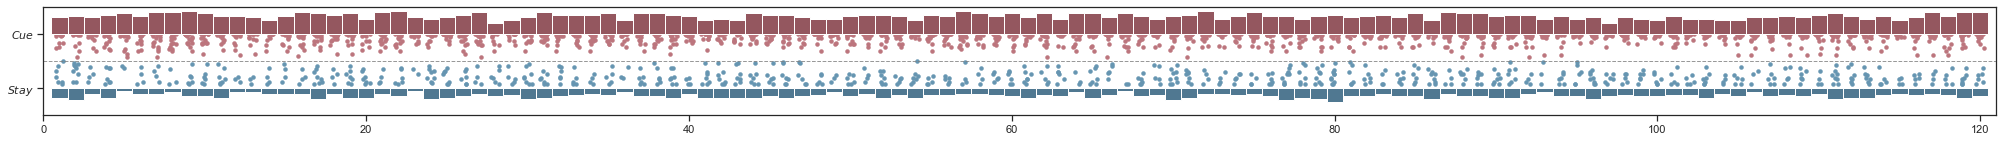

In [101]:
plt.figure(figsize=(35,2))
plt.xlim([0,121])
plt.ylim([-2,2])
plt.yticks([-1,1],[r'$Stay$',r'$Cue$'])
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.0, linestyle='--', color='gray', linewidth=1,alpha=0.8)
plt.bar(np.arange(1,121),(np.array(n_cue)/20),width=1,bottom=1,color=(148/255, 87/255, 95/255))
plt.bar(np.arange(1,121),(-np.array(n_stay)/20),width=1,bottom=-1,color=(80/255, 120/255, 145/255))
for i in range(120):
    fitting_scatter(i+1,np.array(llh_stay[i]),(102/255, 149/255, 177/255))
    fitting_scatter(i+1,np.array(llh_cue[i]),(188/255, 117/255, 125/255))

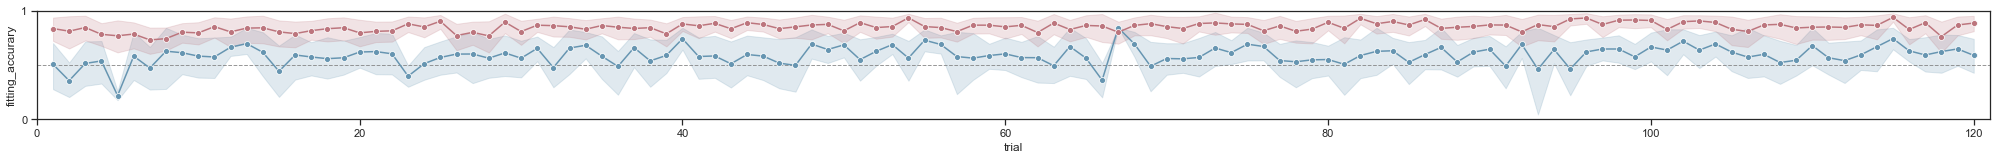

In [ ]:
fitting_accurary_stay = []
fitting_accurary_cue = []
trial_stay = []
trial_cue = []
text_stay = []
text_cue = []
for i in range(len(llh_stay)):
    for j in range(len(llh_stay[i])):
        fitting_accurary_stay.append(-llh_stay[i][j])
        trial_stay.append(i+1)
        text_stay.append('stay')
for i in range(len(llh_cue)):
    for j in range(len(llh_cue[i])):
        fitting_accurary_cue.append(llh_cue[i][j])
        trial_cue.append(i+1)
        text_cue.append('cue')
data = {
    'trial':trial_stay+trial_cue,
    'fitting_accurary':fitting_accurary_stay+fitting_accurary_cue,
    'stay_cue':text_stay+text_cue
}
custom_palette = {
    'stay': (102/255, 149/255, 177/255),  # 红棕色
    'cue': (188/255, 117/255, 125/255)   # 蓝色
}
sns.set_style("ticks")
df = pd.DataFrame(data)
plt.figure(figsize=(35,2))
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.5, linestyle='--', color='gray', linewidth=1,alpha=0.8)
sns.lineplot(data=df, x='trial', y='fitting_accurary',hue='stay_cue',legend=False,palette=custom_palette, marker='o')
plt.yticks([0,1])
plt.ylim(0.0, 1.0)
plt.xlim([0,121])
plt.show()

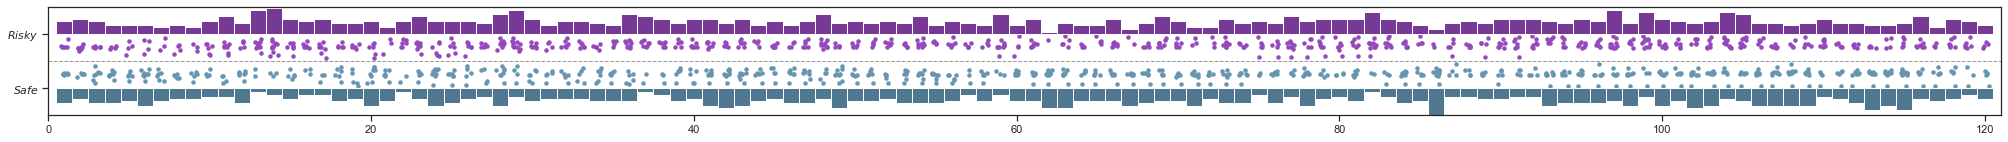

In [102]:
plt.figure(figsize=(35,2))
plt.xlim([0,121])
plt.ylim([-2,2])
plt.yticks([-1,1],[r'$Safe$',r'$Risky$'])
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.0, linestyle='--', color='gray', linewidth=1,alpha=0.8)
plt.bar(np.arange(1,121),(np.array(n_risk_0)/12.5),width=1,bottom=1,color=(118/255, 58/255, 150/255))
plt.bar(np.arange(1,121),(-np.array(n_safe_0)/12.5),width=1,bottom=-1,color=(80/255, 120/255, 145/255))
for i in range(120):
    fitting_scatter(i+1,np.array(llh_risk_0[i]),(148/255, 72/255, 188/255))
    fitting_scatter(i+1,np.array(llh_safe_0[i]),(102/255, 149/255, 177/255))

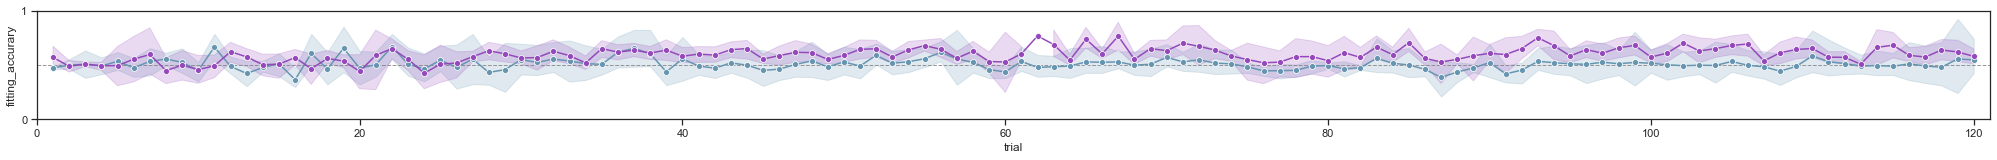

In [103]:
fitting_accurary_safe_0 = []
fitting_accurary_risk_0 = []
trial_safe_0 = []
trial_risk_0 = []
text_safe_0 = []
text_risk_0 = []
for i in range(len(llh_safe_0)):
    for j in range(len(llh_safe_0[i])):
        fitting_accurary_safe_0.append(-llh_safe_0[i][j])
        trial_safe_0.append(i+1)
        text_safe_0.append('safe_0')
for i in range(len(llh_risk_0)):
    for j in range(len(llh_risk_0[i])):
        fitting_accurary_risk_0.append(llh_risk_0[i][j])
        trial_risk_0.append(i+1)
        text_risk_0.append('risk_0')
data = {
    'trial':trial_safe_0+trial_risk_0,
    'fitting_accurary':fitting_accurary_safe_0+fitting_accurary_risk_0,
    'safe_risk':text_safe_0+text_risk_0
}
custom_palette = {
    'safe_0': (102/255, 149/255, 177/255),  # 红棕色
    'risk_0': (148/255, 72/255, 188/255)   # 蓝色
}
sns.set_style("ticks")
df = pd.DataFrame(data)
plt.figure(figsize=(35,2))
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.5, linestyle='--', color='gray', linewidth=1,alpha=0.8)
sns.lineplot(data=df, x='trial', y='fitting_accurary',hue='safe_risk',legend=False,palette=custom_palette, marker='o')
plt.yticks([0,1])
plt.ylim(0.0, 1.0)
plt.xlim([0,121])
plt.show()

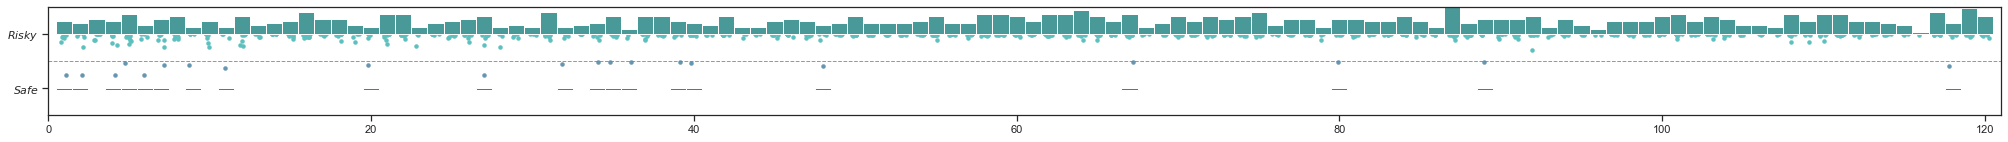

In [104]:
plt.figure(figsize=(35,2))
plt.xlim([0,121])
plt.ylim([-2,2])
plt.yticks([-1,1],[r'$Safe$',r'$Risky$'])
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.0, linestyle='--', color='gray', linewidth=1,alpha=0.8)
plt.bar(np.arange(1,121),(np.array(n_risk_1)/12.5),width=1,bottom=1,color=(72/255, 153/255, 152/255))
plt.bar(np.arange(1,121),(-np.array(n_safe_1)/12.5),width=1,bottom=-1,color=(80/255, 120/255, 145/255))
for i in range(120):
    fitting_scatter(i+1,np.array(llh_risk_1[i]),(91/255, 192/255, 190/255))
    fitting_scatter(i+1,np.array(llh_safe_1[i]),(102/255, 149/255, 177/255))

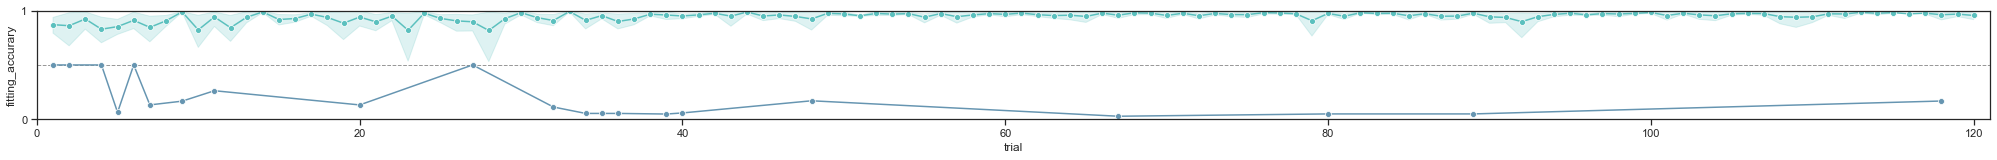

In [105]:
fitting_accurary_safe_1 = []
fitting_accurary_risk_1 = []
trial_safe_1 = []
trial_risk_1 = []
text_safe_1 = []
text_risk_1 = []
for i in range(len(llh_safe_1)):
    for j in range(len(llh_safe_1[i])):
        fitting_accurary_safe_1.append(-llh_safe_1[i][j])
        trial_safe_1.append(i+1)
        text_safe_1.append('safe_1')
for i in range(len(llh_risk_1)):
    for j in range(len(llh_risk_1[i])):
        fitting_accurary_risk_1.append(llh_risk_1[i][j])
        trial_risk_1.append(i+1)
        text_risk_1.append('risk_1')
data = {
    'trial':trial_safe_1+trial_risk_1,
    'fitting_accurary':fitting_accurary_safe_1+fitting_accurary_risk_1,
    'safe_risk':text_safe_1+text_risk_1
}
custom_palette = {
    'safe_1': (102/255, 149/255, 177/255),  # 红棕色
    'risk_1': (91/255, 192/255, 190/255)   # 蓝色
}
sns.set_style("ticks")
df = pd.DataFrame(data)
plt.figure(figsize=(35,2))
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.5, linestyle='--', color='gray', linewidth=1,alpha=0.8)
sns.lineplot(data=df, x='trial', y='fitting_accurary',hue='safe_risk',legend=False,palette=custom_palette, marker='o')
plt.yticks([0,1])
plt.ylim(0.0, 1.0)
plt.xlim([0,121])
plt.show()

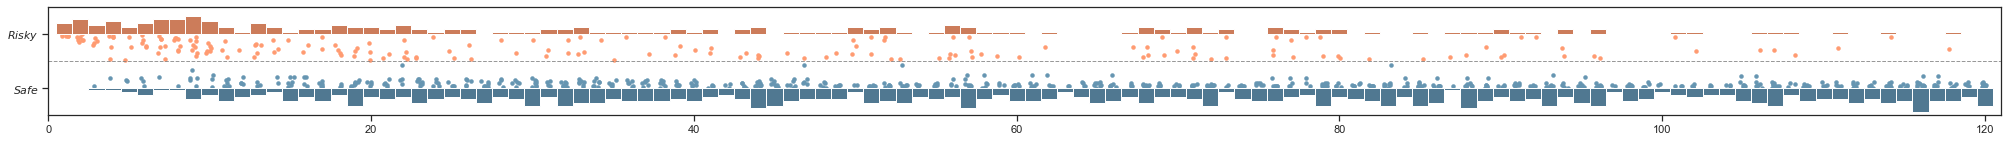

In [106]:
plt.figure(figsize=(35,2))
plt.xlim([0,121])
plt.ylim([-2,2])
plt.yticks([-1,1],[r'$Safe$',r'$Risky$'])
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.0, linestyle='--', color='gray', linewidth=1,alpha=0.8)
plt.bar(np.arange(1,121),(np.array(n_risk_2)/12.5),width=1,bottom=1,color=(204/255, 124/255, 90/255))
plt.bar(np.arange(1,121),(-np.array(n_safe_2)/12.5),width=1,bottom=-1,color=(80/255, 120/255, 145/255))
for i in range(120):
    fitting_scatter(i+1,np.array(llh_risk_2[i]),(255/255, 155/255, 113/255))
    fitting_scatter(i+1,np.array(llh_safe_2[i]),(102/255, 149/255, 177/255))

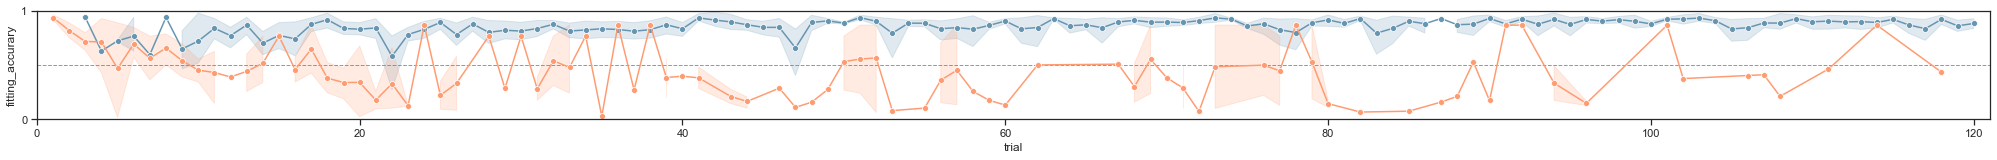

In [107]:
fitting_accurary_safe_2 = []
fitting_accurary_risk_2 = []
trial_safe_2 = []
trial_risk_2 = []
text_safe_2 = []
text_risk_2 = []
for i in range(len(llh_safe_2)):
    for j in range(len(llh_safe_2[i])):
        fitting_accurary_safe_2.append(-llh_safe_2[i][j])
        trial_safe_2.append(i+1)
        text_safe_2.append('safe_2')
for i in range(len(llh_risk_2)):
    for j in range(len(llh_risk_2[i])):
        fitting_accurary_risk_2.append(llh_risk_2[i][j])
        trial_risk_2.append(i+1)
        text_risk_2.append('risk_2')
data = {
    'trial':trial_safe_2+trial_risk_2,
    'fitting_accurary':fitting_accurary_safe_2+fitting_accurary_risk_2,
    'safe_risk':text_safe_2+text_risk_2
}
custom_palette = {
    'safe_2': (102/255, 149/255, 177/255),  # 红棕色
    'risk_2': (255/255, 155/255, 113/255)   # 蓝色
}
sns.set_style("ticks")
df = pd.DataFrame(data)
plt.figure(figsize=(35,2))
plt.plot(np.arange(0,122), np.ones(len(np.arange(0,122))) * 0.5, linestyle='--', color='gray', linewidth=1,alpha=0.8)
sns.lineplot(data=df, x='trial', y='fitting_accurary',hue='safe_risk',legend=False,palette=custom_palette, marker='o')
plt.yticks([0,1])
plt.ylim(0.0, 1.0)
plt.xlim([0,121])
plt.show()

In [33]:
n=0
for i in range(120):
    n+=n_risk_0[i]+n_safe_0[i]+n_risk_1[i]+n_safe_1[i]+n_risk_2[i]+n_safe_2[i]
print(n)

3000


In [13]:
print(np.sum(LL))
print(np.sum(LL_rl))
print(np.sum(LL_m_rl))

-2079.044241460037
-3139.5455499381064
-2700.870917345198


In [16]:
BIC_ai = -np.sum(LL)*2+5*np.log(6000)
BIC_rl = -np.sum(LL_rl)*2+2*np.log(6000)
BIC_m_rl = -np.sum(LL_m_rl)*2+3*np.log(6000)

In [17]:
import matplotlib.pyplot as plt  
import seaborn as sns

<Figure size 432x288 with 0 Axes>

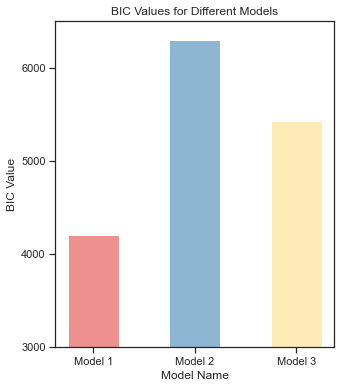

In [18]:

sns.set(style='ticks')  
sns.despine()
# 假设你有以下三个模型的BIC值  
bic_values = [BIC_ai, BIC_rl, BIC_m_rl]  # 这里只是示例值，你应该替换成你的实际BIC值  
model_names = ['Model 1', 'Model 2', 'Model 3']  
plt.figure(figsize=(5,6))
# 绘制柱形图  
plt.bar(model_names, bic_values, color=[(238/255,144/255,141/255), (141/255,182/255,211/255), (255/255, 235/255, 184/255)],width=0.5)  # 使用不同的颜色  

# 添加标题和轴标签  
plt.title('BIC Values for Different Models')  
plt.xlabel('Model Name')  
plt.ylabel('BIC Value')  
plt.ylim(ymin=3000,ymax=6500)
plt.yticks([3000,4000,5000,6000])
# 显示图形  
plt.show()

In [ ]:
def P_active_inference_subject_25(rate,prior,p_al,p_ai,p_ex):
    trial_num = 120
    subject = 24
    
    if_can_ask,action_stay_cue,result_stay_cue,action_safe_risk,result_safe_risk = read_behavioral_data(subject)
    log_p_policy = 0

    a = np.array([[100.0,100,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,prior,prior,0,0,0,0],
                [0,0,0,0,100,100,0,0],
                [0,0,0,0,0,0,100,0],
                [0,0,0,0,0,0,0,100]])
    A = dir(a)
    for j in range(trial_num):
        log_p_policy += np.log(P_stay_cue(A,a,action_stay_cue[j],if_can_ask[j],p_al,p_ai,p_ex))
        log_p_policy += np.log(P_safe_risk(A,a,action_safe_risk[j],result_stay_cue[j],p_al,p_ai,p_ex))
        a = a_update(a,result_stay_cue[j],result_safe_risk[j],action_safe_risk[j],rate)
        A = dir(a)
    return log_p_policy